In [1]:
import os
import random
import time
import h5py
import numpy as np
import pandas as pd
import scipy.io
import librosa
import kagglehub
import h5py
import shutil
import IPython.display as ipd

from IPython.display import display, Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score 
from sktime.classification.kernel_based import RocketClassifier
from sktime.transformations.panel.rocket import Rocket
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, classification_report
from detach_rocket.detach_classes import DetachRocket


In [2]:
# ==================================================
# 2. CARGA Y CONCATENACIÓN DE BABBLE NOISE (LOCAL)
# ==================================================
babble_exact_path = "datasets/noise/0dB/valid/real" 

audio_buffers_list = []
max_archivos_a_combinar = 40 
sr_original = 16000
sr_objetivo = 22050

archivos_mat = 0

for f in os.listdir(babble_exact_path):
    if len(audio_buffers_list) >= max_archivos_a_combinar:
        break

    file_path = os.path.join(babble_exact_path, f)
    
    if file_path.endswith('.mat'):
            mat_contents = scipy.io.loadmat(file_path) #esta funcion convierte el .mat en un diccionario 
            keys = [k for k in mat_contents.keys() if not k.startswith('__')] # cuando SciPy lee un .mat, automáticamente le inyecta variables internas de configuración que siempre empiezan con doble guion bajo (ej: __header. 
            #armo una lista solo con los nombres de las variables "reales" que contienen el audio
            if keys:
                audio_raw = mat_contents[keys[0]].flatten().astype(np.float32) 
                #mat_contents[keys[0]] extrae los datos almacenados en la primera clave válida
                # .flatten(): "aplasta" esa matriz para convertirla en un vector 1D
                # .astype(np.float32): conversión a formato decimal de 32 bits (float32).
                if audio_raw.size > 0:
                    audio_buffers_list.append(audio_raw)
                    archivos_mat += 1

# Procesamiento final
print("-" * 50)
print("Estadísticas de carga directa:")
print(f" - Archivos .mat procesados con éxito: {archivos_mat}")

babble_completo_16k = np.concatenate(audio_buffers_list)
babble_audio_full = librosa.resample(babble_completo_16k, orig_sr=sr_original, target_sr=sr_objetivo) #la paso a la sample rate que necesito

--------------------------------------------------
Estadísticas de carga directa:
 - Archivos .mat procesados con éxito: 40


In [3]:
# ==================================================
# 3. FUNCIONES DE DATA AUGMENTATION
# ==================================================
def add_white_noise(audio, noise_level=0.005):
    noise = np.random.randn(len(audio)) #vector de numeros aleatorios con la misma longitud que mi vector original
    return audio + noise_level * noise

def add_pink_noise(audio, noise_level=0.01):
    #el ruido rosa se caracteriza por tener una densidad espectral inversa a la frecuencia (es decir, 1/f)
    white = np.random.randn(len(audio)) #genero ruido blanco
    fft_white = np.fft.rfft(white) #transformada de fourier - paso el ruido blanco a dominio de la frecuencia. Ya no es la potencia, es la amplitud la que veo representada
    frequencies = np.maximum(np.fft.rfftfreq(len(audio)), 1e-10) #crea un vector de frecuencias. SI hay un valor menor a 1e-10, lo reemplaza por este número.
    #Elijo 1e-10 porque es un numero cercano a cero, sin ser cero.
    f_filter = 1.0 / np.sqrt(frequencies) #En la línea anterior, me aseguré de que no queden divisiones por cero. V^2 = P -> 1/sqrt(f) = P (ver notas)
    f_filter /= np.max(f_filter) #Busca el numero mas grande que haya quedado dentro del array y divide a todos los valores por este numero
    fft_pink = fft_white * f_filter #Aplica el filtro al ruido blanco en el dominio de la frecuencia.
    pink = np.fft.irfft(fft_pink, n=len(audio)) #Conversion al dominio del tiempo
    pink = pink / np.max(np.abs(pink)) #normalizacion
    return audio + noise_level * pink

def add_babble_noise(audio, babble_audio, noise_level=0.03):
    # np.tile -> construye un nuevo array repitiendo el primer argumento (en este caso, babble_audio) la cantidad de veces que se pida. 
    # Esto se aplica solo si el audio es menor al audio original  
    #np.ceil -> devuelve el menor escalar i tal que i>=x
    if len(babble_audio) < len(audio):
        babble_audio = np.tile(babble_audio, int(np.ceil(len(audio) / len(babble_audio))))

    # toma un punto de inicio random
    start_idx = random.randint(0, len(babble_audio) - len(audio))
    babble_chunk = babble_audio[start_idx : start_idx + len(audio)] #aplico babble noise desde mi punto random hasta el final del audio
    babble_chunk = babble_chunk / (np.max(np.abs(babble_chunk)) + 1e-10) #normalizo el murmullo para que no haya picos de volumen descontrolados

    return audio + noise_level * babble_chunk 


In [4]:
# ==========================================
# 4. DESCARGA Y CURACIÓN DEL DATASET LOCAL
# ==========================================
dataset_root_path = kagglehub.dataset_download("mmoreaux/environmental-sound-classification-50")

metadata_path = None
for root, dirs, files in os.walk(dataset_root_path):
    if 'esc50.csv' in files:
        metadata_path = os.path.join(root, 'esc50.csv')
        break

if metadata_path:
    df = pd.read_csv(metadata_path)
    print("Archivo de metadatos cargado correctamente.")

mis_clases = ['clock_alarm', 'door_wood_knock', 'cat', 'crying_baby', 'dog', 'glass_breaking']
df_filtrado = df[df['category'].isin(mis_clases)].copy()

kaggle_audio_dir = None
for root, dirs, files in os.walk(dataset_root_path): #Busca donde estan los archivos
    if any(f.endswith('.wav') for f in files):
        kaggle_audio_dir = root
        break

target_dir = "datasets/audios_originales"
archivos_copiados = 0

for index, row in df_filtrado.iterrows():
    src_path = os.path.join(kaggle_audio_dir, row['filename'])
    dst_path = os.path.join(target_dir, row['filename'])
    
    # Solo lo copio si el archivo original existe y no esta en el directorio audios_originales
    if os.path.exists(src_path) and not os.path.exists(dst_path):
        shutil.copy2(src_path, dst_path)
        archivos_copiados += 1

print(f"Se copiaron {archivos_copiados} archivos nuevos.")


Archivo de metadatos cargado correctamente.
Se copiaron 0 archivos nuevos.


In [5]:
for index, row in df_filtrado.iterrows(): #iterrows devuelve el indice y el contenido de la fila 
    file_path = print(row['filename'])
    # categoria = print(row['category'])


1-100032-A-0.wav
1-101336-A-30.wav
1-103995-A-30.wav
1-103999-A-30.wav
1-110389-A-0.wav
1-13613-A-37.wav
1-14262-A-37.wav
1-187207-A-20.wav
1-20133-A-39.wav
1-211527-A-20.wav
1-211527-B-20.wav
1-211527-C-20.wav
1-22694-A-20.wav
1-22694-B-20.wav
1-26188-A-30.wav
1-30226-A-0.wav
1-30344-A-0.wav
1-32318-A-0.wav
1-34094-A-5.wav
1-34094-B-5.wav
1-34853-A-37.wav
1-47819-A-5.wav
1-47819-B-5.wav
1-47819-C-5.wav
1-52290-A-30.wav
1-56380-A-5.wav
1-56380-B-5.wav
1-59513-A-0.wav
1-60997-A-20.wav
1-60997-B-20.wav
1-67033-A-37.wav
1-72195-A-37.wav
1-72195-B-37.wav
1-74517-A-37.wav
1-79113-A-5.wav
1-81001-A-30.wav
1-81001-B-30.wav
1-82817-A-30.wav
1-84536-A-39.wav
1-84704-A-39.wav
1-84705-A-39.wav
1-85168-A-39.wav
1-85184-A-39.wav
1-85362-A-0.wav
1-88807-A-39.wav
1-96890-A-37.wav
1-97392-A-0.wav
1-977-A-39.wav
2-102435-A-37.wav
2-104475-A-37.wav
2-104476-A-37.wav
2-106881-A-39.wav
2-107351-A-20.wav
2-107351-B-20.wav
2-110010-A-5.wav
2-110011-A-5.wav
2-112213-A-39.wav
2-112213-B-39.wav
2-114254-A-30.w

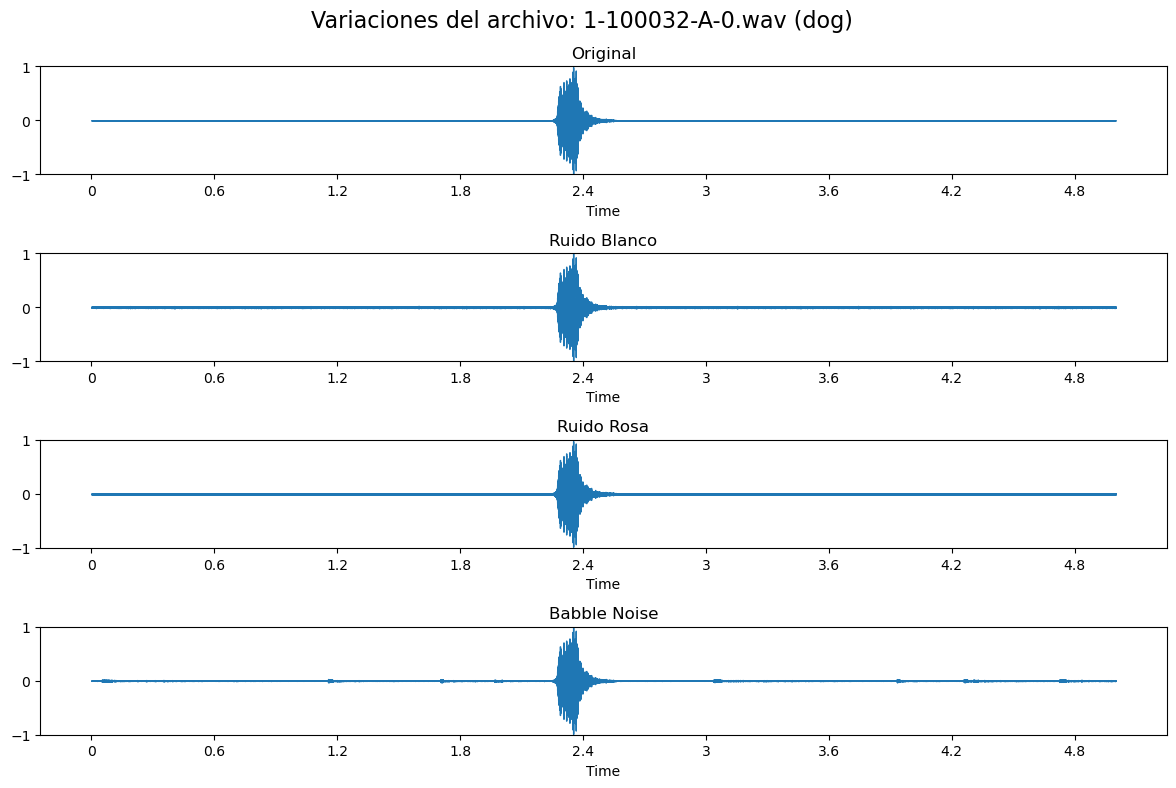

In [19]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(12, 8))
plt.suptitle(f"Variaciones del archivo: {groups[0]} ({y[0]})", fontsize=16)

nombres = ["Original", "Ruido Blanco", "Ruido Rosa", "Babble Noise"]

for i in range(4):
    plt.subplot(4, 1, i+1)
    # librosa.display.waveshow grafica la onda en el tiempo
    librosa.display.waveshow(X[i].squeeze(), sr=22050)
    plt.title(nombres[i])
    plt.ylim(-1, 1) # Mantenemos la misma escala para notar la diferencia
    plt.tight_layout()

plt.show()

In [ ]:
import matplotlib.pyplot import plt
import librosa.display

plt.figure(figsize=(12, 8))
plt.suptitle(f"Variaciones del archivo: {groups[0]} ({y[0]})", fontsize=16)

nombres = ["Original", "Ruido Blanco", "Ruido Rosa", "Babble Noise"]

for i in range(4):
    plt.subplot(4, 1, i+1)
    # librosa.display.waveshow grafica la onda en el tiempo
    librosa.display.waveshow(X[i].squeeze(), sr=22050)
    plt.title(nombres[i])
    plt.ylim(-1, 1) # Mantenemos la misma escala para notar la diferencia
    plt.tight_layout()

plt.show()

SyntaxError: invalid syntax (3341914514.py, line 1)

In [20]:
import numpy as np

print("Prueba de clonación accidental:")
print("¿Original == Ruido Blanco?:", np.array_equal(X[0], X[1]))
print("¿Original == Ruido Rosa?:  ", np.array_equal(X[0], X[2]))
print("¿Original == Babble Noise?:", np.array_equal(X[0], X[3]))

Prueba de clonación accidental:
¿Original == Ruido Blanco?: False
¿Original == Ruido Rosa?:   False
¿Original == Babble Noise?: False


In [11]:
# ==========================================
# 5. TRANSFORMACIÓN Y DATA AUGMENTATION
# ==========================================
correct_audio_dir = target_dir 

X_list = []
y_list = []
groups = []


for index, row in df_filtrado.iterrows(): #iterrows devuelve el indice y el contenido de la fila 
    file_path = os.path.join(correct_audio_dir, row['filename']) #ejemplo: datasets/audios_originales/1-211527-C-20.wav
    categoria = row['category'] #ejemplo: crying_baby
    
    y_audio, sr = librosa.load(file_path, sr=22050) #lee audio y lo convierte

    audios_a_procesar = [
            y_audio,                                     
            add_white_noise(y_audio),                    
            add_pink_noise(y_audio),                     
            add_babble_noise(y_audio, babble_audio_full) 
        ]

    for audio_version in audios_a_procesar:
        X_list.append(audio_version)
        y_list.append(categoria)
        groups.append(row['filename'])

X = np.array(X_list)
y = np.array(y_list)
groups = np.array(groups)

print("-" * 50)
print(f"Forma final de la matriz X: {X.shape}")
print(f"Cantidad de etiquetas y: {y.shape}")


--------------------------------------------------
Forma final de la matriz X: (960, 110250)
Cantidad de etiquetas y: (960,)


In [ ]:
groups
y

array(['1-100032-A-0.wav', '1-100032-A-0.wav', '1-100032-A-0.wav',
       '1-100032-A-0.wav', '1-101336-A-30.wav', '1-101336-A-30.wav',
       '1-101336-A-30.wav', '1-101336-A-30.wav', '1-103995-A-30.wav',
       '1-103995-A-30.wav', '1-103995-A-30.wav', '1-103995-A-30.wav',
       '1-103999-A-30.wav', '1-103999-A-30.wav', '1-103999-A-30.wav',
       '1-103999-A-30.wav', '1-110389-A-0.wav', '1-110389-A-0.wav',
       '1-110389-A-0.wav', '1-110389-A-0.wav', '1-13613-A-37.wav',
       '1-13613-A-37.wav', '1-13613-A-37.wav', '1-13613-A-37.wav',
       '1-14262-A-37.wav', '1-14262-A-37.wav', '1-14262-A-37.wav',
       '1-14262-A-37.wav', '1-187207-A-20.wav', '1-187207-A-20.wav',
       '1-187207-A-20.wav', '1-187207-A-20.wav', '1-20133-A-39.wav',
       '1-20133-A-39.wav', '1-20133-A-39.wav', '1-20133-A-39.wav',
       '1-211527-A-20.wav', '1-211527-A-20.wav', '1-211527-A-20.wav',
       '1-211527-A-20.wav', '1-211527-B-20.wav', '1-211527-B-20.wav',
       '1-211527-B-20.wav', '1-211527-B-

In [12]:



from sklearn.model_selection import GroupKFold

# 1. Instanciamos el validador
gkf_prueba = GroupKFold(n_splits=5)

print("🕵️‍♀️ Iniciando auditoría de filtración de datos (Data Leakage)...")

# 2. Hacemos solo UNA partición de prueba
for train_index, test_index in gkf_prueba.split(X, y_encoded, groups=groups):
    
    # Extraemos los "apellidos" (filenames) que cayeron en la bolsa de Train y en la de Test
    grupos_en_train = set(groups[train_index])
    grupos_en_test = set(groups[test_index])
    print(f"Test{grupos_en_test}")
    print(f"Train{grupos_en_train}")
    
    # 3. La prueba matemática: Intersección de conjuntos
    # Busca si hay algún filename que exista en AMBAS bolsas al mismo tiempo
    infiltrados = grupos_en_train.intersection(grupos_en_test)
    
    print("-" * 50)
    print(f"Archivos base (únicos) usados para Estudiar (Train): {len(grupos_en_train)}")
    print(f"Archivos base (únicos) usados para el Examen (Test): {len(grupos_en_test)}")
    print(f"🚨 Archivos que se filtraron en ambos lados: {len(infiltrados)}")
    print("-" * 50)
    
    if len(infiltrados) == 0:
        print("✅ PRUEBA SUPERADA CIENTÍFICAMENTE.")
        print("Ninguna variante de ruido fue separada de su audio original.")
    else:
        print("❌ ALERTA: Hubo contaminación cruzada.")
        
    break # Frenamos el bucle, con auditar el primer fold alcanza

🕵️‍♀️ Iniciando auditoría de filtración de datos (Data Leakage)...


NameError: name 'y_encoded' is not defined

In [13]:
# ==========================================
# 5. DETACH ROCKET 
# ==========================================


le = LabelEncoder() #convierte text labels en numeros del 0 a nro_de_clases - 1
y_encoded = le.fit_transform(y)

gkf = GroupKFold(n_splits=5) # me aseguro de que el audio original y sus deformaciones queden todos en train/test

accuracies = [] #guardo resultado de cada fold para despues hacer un promedio

print("-" * 50)
print(f"Total de muestras aumentadas: {len(X)}")

for fold, (train_index, test_index) in enumerate(gkf.split(X, y_encoded, groups=groups)): #gkf.split mira los datos, las etiquetas y los identificadores del archivo original y decide de forma inteligente que numeros de fila se usaran para train y test
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
    detach_model = RocketClassifier(num_kernels=500)
    
    # Entrenamiento
    detach_model.fit(X_train, y_train)
    
    # Evaluación
    y_pred = detach_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    print(f" - Fold {fold+1}: Accuracy = {acc:.4f}")

# 4. Resultado final (la media de todos los folds)
print("-" * 50)
print(f"Accuracy Promedio (Validado): {np.mean(accuracies):.4f}")

--------------------------------------------------
Total de muestras aumentadas: 960


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


 - Fold 1: Accuracy = 0.8281
 - Fold 2: Accuracy = 0.7865
 - Fold 3: Accuracy = 0.9167
 - Fold 4: Accuracy = 0.8906
 - Fold 5: Accuracy = 0.6562
--------------------------------------------------
Accuracy Promedio (Validado): 0.8156


In [ ]:
# ==========================================
# 5. DETACH ROCKET 
# ==========================================


le = LabelEncoder() #convierte text labels en numeros del 0 a nro_de_clases - 1
y_encoded = le.fit_transform(y)

gkf = GroupKFold(n_splits=5) # me aseguro de que el audio original y sus deformaciones queden todos en train/test

accuracies = [] #guardo resultado de cada fold para despues hacer un promedio

print("-" * 50)
print(f"Total de muestras aumentadas: {len(X)}")

for fold, (train_index, test_index) in enumerate(gkf.split(X, y_encoded, groups=groups)): #gkf.split mira los datos, las etiquetas y los identificadores del archivo original y decide de forma inteligente que numeros de fila se usaran para train y test
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
model_type = "rocket"
num_kernels = 10000

DetachRocketModel = DetachRocket(model_type, num_kernels=num_kernels)
# 4. Resultado final (la media de todos los folds)
print("-" * 50)
print(f"Accuracy Promedio (Validado): {np.mean(accuracies):.4f}")

In [19]:
# ==========================================
# 5. ENTRENAMIENTO CON DETACH-ROCKET
# ==========================================
from sklearn.ensemble import RandomForestClassifier
le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("-" * 50)
print("RESUMEN DE AUDIOS UTILIZADOS:")
print(f"Total de muestras (con Data Augmentation): {len(X)}")
print(f" - Muestras para Entrenamiento: {len(X_train)}")
print(f" - Muestras para Prueba (Test): {len(X_test)}")
print("-" * 50)

inicio = time.time()

# Instanciar y ajustar Detach-ROCKET
detach_model = RocketClassifier(num_kernels=500)
detach_model.fit(X_train, y_train)

--------------------------------------------------
RESUMEN DE AUDIOS UTILIZADOS:
Total de muestras (con Data Augmentation): 480
 - Muestras para Entrenamiento: 384
 - Muestras para Prueba (Test): 96
--------------------------------------------------


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


RocketClassifier(num_kernels=500)

In [20]:

# Hacer predicciones sobre el conjunto de prueba
y_pred = detach_model.predict(X_test)

# Calcular la métrica con sklearn
accuracy = accuracy_score(y_test, y_pred)


In [31]:
accuracy

1.0

In [ ]:



# Hacer predicciones sobre el conjunto de prueba
y_pred = detach_model.predict(X_test)

# Calcular la métrica con sklearn
accuracy = accuracy_score(y_test, y_pred)
fin = time.time()

print(f"Precisión (Test Accuracy): {accuracy * 100:.2f}%")
print(f"Tiempo total de ejecución: {fin - inicio:.2f} segundos")

# DetachRocket permite visualizar qué proporción de variables (features) retuvo:
if hasattr(detach_model, 'feature_proportion_'):
    print(f"Porcentaje de features retenidas tras el podado: {detach_model.feature_proportion_ * 100:.2f}%")

# ==========================================
# 6. AUDICIÓN DE VARIANTES
# ==========================================
if 'df_filtrado' in locals() and 'correct_audio_dir' in locals() and correct_audio_dir is not None:
    random_row = df_filtrado.sample(n=1).iloc[0]
    random_file_path = os.path.join(correct_audio_dir, random_row['filename'])
    random_label = random_row['category']

    print("=" * 50)
    print(f"AUDICIÓN DE VARIANTES: {random_label.upper()}")
    print(f"Archivo base: {random_row['filename']}")
    print("=" * 50)

    try:
        y_audio_test, sr_audio = librosa.load(random_file_path, sr=22050)
        
        print("\n1. Audio Original:")
        display(ipd.Audio(y_audio_test, rate=sr_audio))
        
        print("\n2. Variante: Ruido Blanco:")
        y_white = add_white_noise(y_audio_test)
        display(ipd.Audio(y_white, rate=sr_audio))
            
        print("\n3. Variante: Ruido Rosa:")
        y_pink = add_pink_noise(y_audio_test)
        display(ipd.Audio(y_pink, rate=sr_audio))
            
        if babble_audio_full is not None:
            print("\n4. Variante: Murmullo de fondo (Babble Noise):")
            y_babble = add_babble_noise(y_audio_test, babble_audio_full)
            display(ipd.Audio(y_babble, rate=sr_audio))
        else:
            print("\n[Aviso: No se generó Babble Noise válido]")
        
    except Exception as e:
        print(f"Error interno al intentar procesar los audios: {e}")

--------------------------------------------------
RESUMEN DE AUDIOS UTILIZADOS:
Total de muestras (con Data Augmentation): 480
 - Muestras para Entrenamiento: 384
 - Muestras para Prueba (Test): 96
--------------------------------------------------


ValueError: Found input variables with inconsistent numbers of samples: [1, 384]